<a href="https://colab.research.google.com/github/reezyhudson865/DataProjects/blob/main/RHudson_RamenRating_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Module 7 Lab**

The following lab was completed in an undergrad Data Science class at UT-Knoxville in the Spring 2026 semester. The lab follows comparative visualization and analysis of a dataset about ramen noodles. It includes histagrams, lollipop charts, bar charts, stacked bar charts, scatterplot, and heatmaps. The lab objective was outlined by the professor. All rights reserved.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv('ramen-ratings.csv')

In [ ]:
df.head()

,Brand,Variety,Style,Country,Stars
0,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75
1,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1.00
2,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25
3,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75
4,Ching's Secret,Singapore Curry,Pack,India,3.75


In [ ]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2577 entries, 0 to 2576
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Brand    2577 non-null   object 
 1   Variety  2577 non-null   object 
 2   Style    2575 non-null   object 
 3   Country  2577 non-null   object 
 4   Stars    2577 non-null   float64
dtypes: float64(1), object(4)
memory usage: 100.8+ KB


,Brand,Variety,Style,Country,Stars
count,2577,2577,2575,2577,2577.000000
unique,355,2410,7,38,NaN
top,Nissin,Beef,Pack,Japan,NaN
freq,381,7,1528,352,NaN
mean,NaN,NaN,NaN,NaN,3.654676
std,NaN,NaN,NaN,NaN,1.015331
min,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,3.250000
50%,NaN,NaN,NaN,NaN,3.750000
75%,NaN,NaN,NaN,NaN,4.250000


# Summary

The dataset is a collection of qualitative data on ramens. The descriptors in the 5 columns include country of origin, package style, brand, and flavor variety. They then include a quantitative star rating 1-5. There are 2577 entries total.

# Distribution Analysis

In [ ]:
#clean stars
#convert stars from object to numeric
#drop null

df['Stars'] = pd.to_numeric(df['Stars'], errors='coerce')
df = df.dropna(subset=['Stars'])

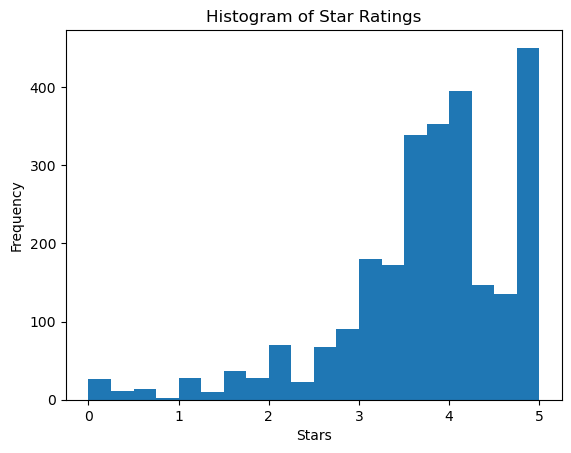

In [ ]:
#histogram of star ratings

plt.figure()
plt.hist(df['Stars'], bins=20)
plt.title('Histogram of Star Ratings')
plt.xlabel('Stars')
plt.ylabel('Frequency')
plt.show()

<Figure size 640x480 with 0 Axes>

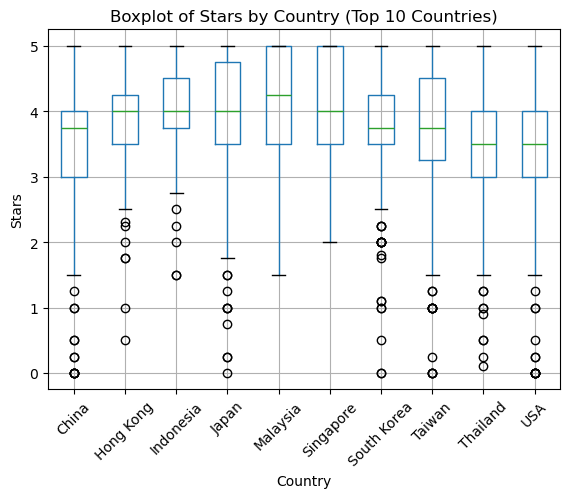

In [ ]:
#box plot of stars (top 10 countries)

top10 = df["Country"].value_counts().head(10).index
df_top = df[df["Country"].isin(top10)]

plt.figure()
df_top.boxplot(column="Stars", by="Country")
plt.title("Boxplot of Stars by Country (Top 10 Countries)")
plt.suptitle("")
plt.xticks(rotation=45)
plt.ylabel("Stars")
plt.show()

# Comparison Across Groups

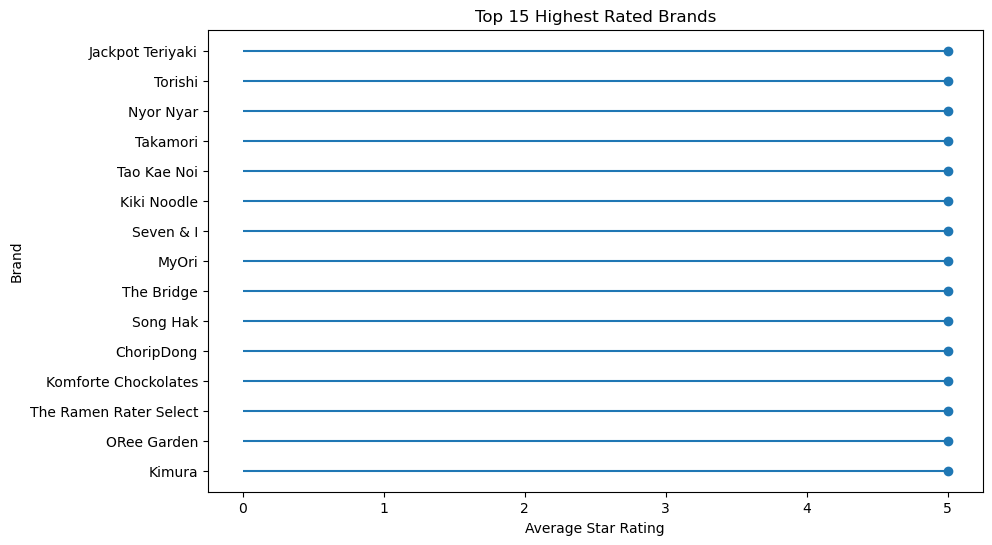

In [ ]:
#lollipop chart, top 15 highest rated brands

#get top brands by avg stars
brand_avg = df.groupby("Brand")["Stars"].mean()
top15 = brand_avg.sort_values(ascending=False).head(15)

#chart
plt.figure(figsize=(10,6))
plt.hlines(y=top15.index, xmin=0, xmax=top15.values)
plt.plot(top15.values, top15.index, "o")
plt.title("Top 15 Highest Rated Brands")
plt.xlabel("Average Star Rating")
plt.ylabel("Brand")

plt.show()

The top 15 brands listed above all appear to average around a 5 star rating.

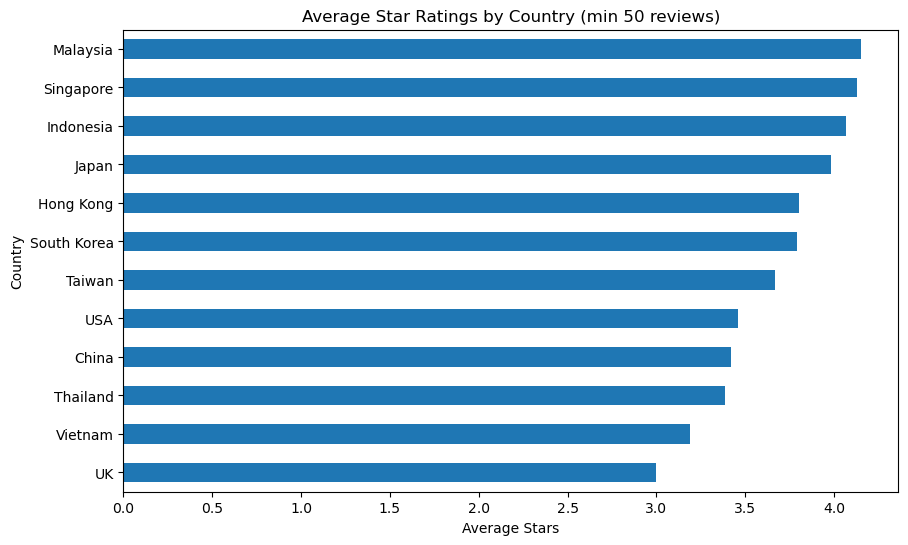

In [ ]:
#average stars by country, minimum review threshold

df["Stars"] = pd.to_numeric(df["Stars"], errors="coerce")
df = df.dropna(subset=["Stars", "Country"])

#minimum review threshold
min_reviews = 50
country_counts = df["Country"].value_counts()
valid_countries = country_counts[country_counts >= min_reviews].index
df_filtered = df[df["Country"].isin(valid_countries)]

country_avg = df_filtered.groupby("Country")["Stars"].mean()

country_avg = country_avg.sort_values()

plt.figure(figsize=(10,6))
country_avg.plot(kind="barh")

plt.title("Average Star Ratings by Country (min 50 reviews)")
plt.xlabel("Average Stars")
plt.ylabel("Country")

plt.show()

Malaysia takes the top spot for the country with the highest average star rating, reaching around a 4.0.

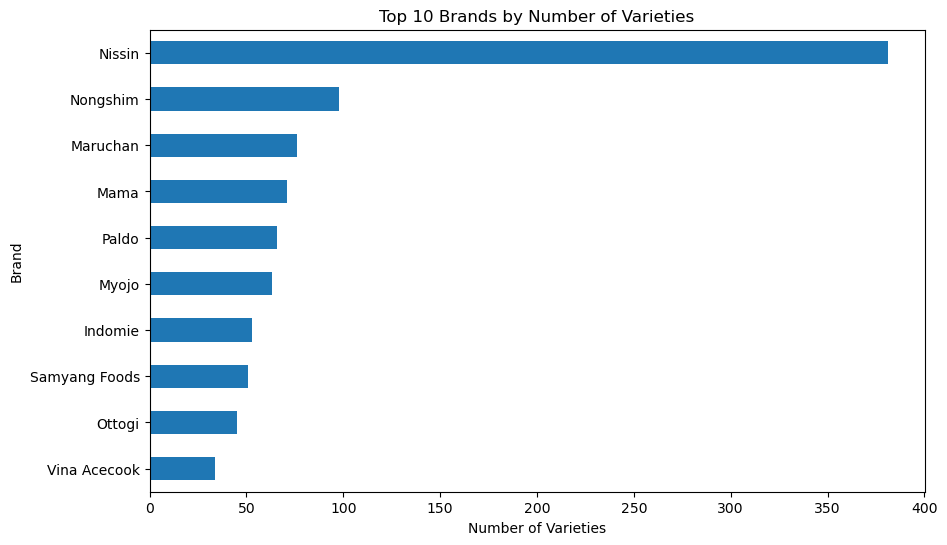

In [ ]:
#top 10 brands by number of varieties

brand_counts = df["Brand"].value_counts().head(10)

plt.figure(figsize=(10,6))
brand_counts.sort_values().plot(kind="barh")

plt.title("Top 10 Brands by Number of Varieties")
plt.xlabel("Number of Varieties")
plt.ylabel("Brand")

plt.show()

The brand Nissin takes the top spot for the greatest number of varieties, reaching close to 400 varieties of ramen. This towers over Nongshim at number 2, who has just above 100 varieties.

<Figure size 1200x700 with 0 Axes>

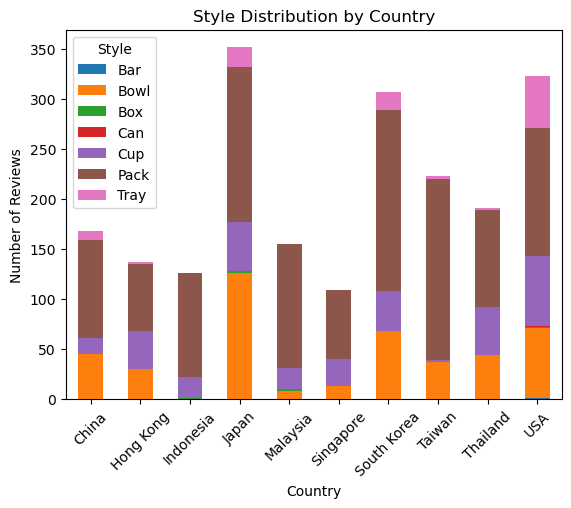

In [ ]:
#style distribution by country, stacked bar chart

df = df.dropna(subset=["Country", "Style"])

top_countries = df["Country"].value_counts().head(10).index
df = df[df["Country"].isin(top_countries)]

style_country = pd.crosstab(df["Country"], df["Style"])

plt.figure(figsize=(12,7))
style_country.plot(kind="bar", stacked=True)
plt.title("Style Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

All top 10 countries listed show a dominance in the pack style. However, ranges for other styles like bowl, cup, and tray depended on the country, with some countries seeing more bowls than cups, and vice versa.

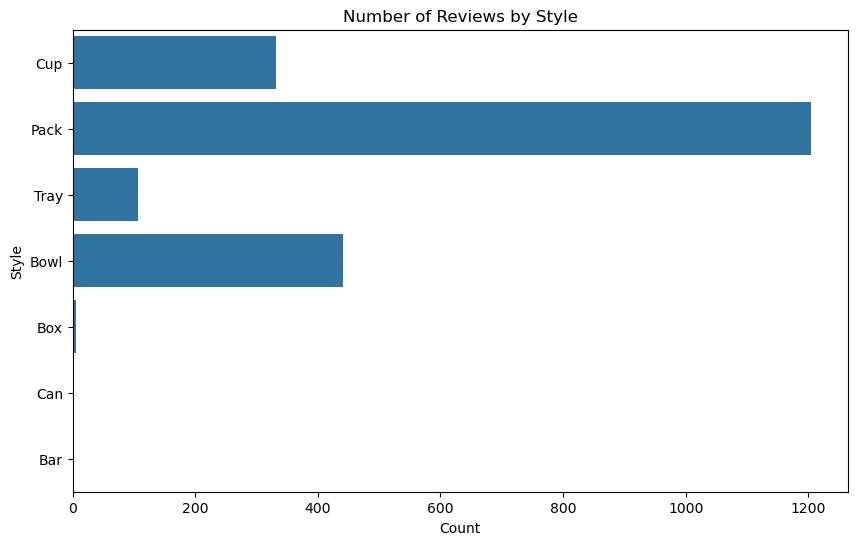

In [ ]:
#countplot, number of reviews by style

df = df.dropna(subset=["Style"])

plt.figure(figsize=(10,6))
sns.countplot(data=df, y="Style")
plt.title("Number of Reviews by Style")
plt.xlabel("Count")
plt.ylabel("Style")
plt.show()

Packaged ramen has a clear dominance over other styles of ramen sold in the dataset of reviews. Box ramen is the least common style implicated in the reviews.

# Relationship and Trend Analysis

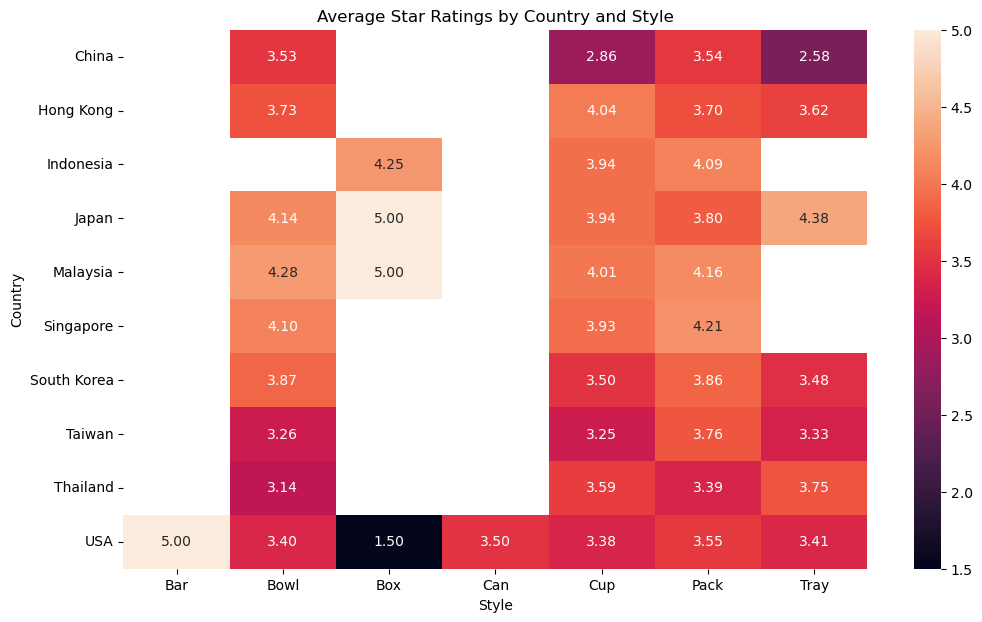

In [ ]:
#heatmap, avg stars by country and style

df["Stars"] = pd.to_numeric(df["Stars"], errors="coerce")
df = df.dropna(subset=["Stars", "Country", "Style"])

heatmap_data = df.pivot_table(
    values="Stars",
    index="Country",
    columns="Style",
    aggfunc="mean"
)

plt.figure(figsize=(12,7))
sns.heatmap(heatmap_data, annot=True, fmt=".2f")
plt.title("Average Star Ratings by Country and Style")
plt.xlabel("Style")
plt.ylabel("Country")
plt.show()

Japan and Malaysia maintain the highest averages for boxed ramen with 5.0s. The USA maintains the lowest average overall in all styles for their boxed ramen.

In [ ]:
#create year column

np.random.seed(42)
df["Year"] = np.random.randint(2002, 2018, size=len(df))

df.head()

,Brand,Variety,Style,Country,Stars,Year
0,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75,2008
1,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1.00,2005
2,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25,2014
3,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75,2016
5,Samyang Foods,Kimchi song Song Ramen,Pack,South Korea,4.75,2012


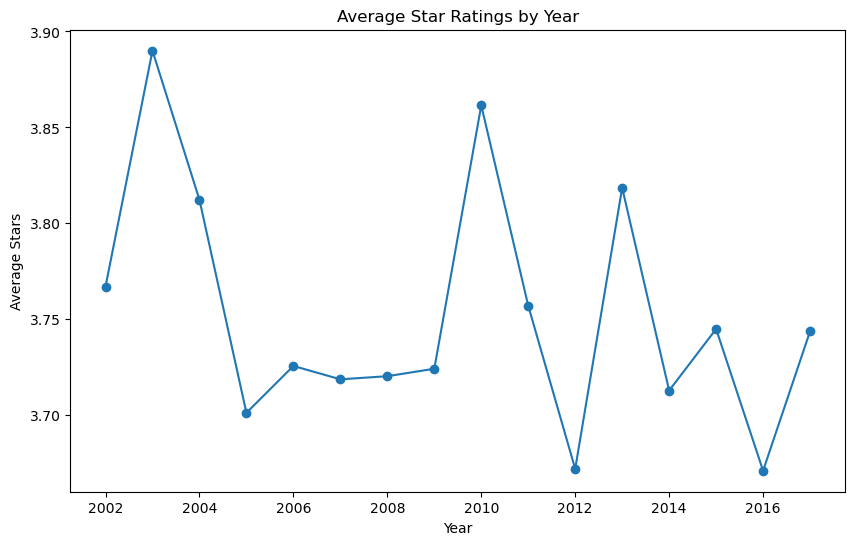

In [ ]:
#line plot, average stars by year

df["Stars"] = pd.to_numeric(df["Stars"], errors="coerce")
df = df.dropna(subset=["Stars"])

avg_year = df.groupby("Year")["Stars"].mean().sort_index()

plt.figure(figsize=(10,6))
plt.plot(avg_year.index, avg_year.values, marker="o")
plt.title("Average Star Ratings by Year")
plt.xlabel("Year")
plt.ylabel("Average Stars")
plt.show()

2003 saw the highest average star ratings, with 2012 and 2016 tying for lowing average star rating years. The line chart follows no particular linear trend up or down.

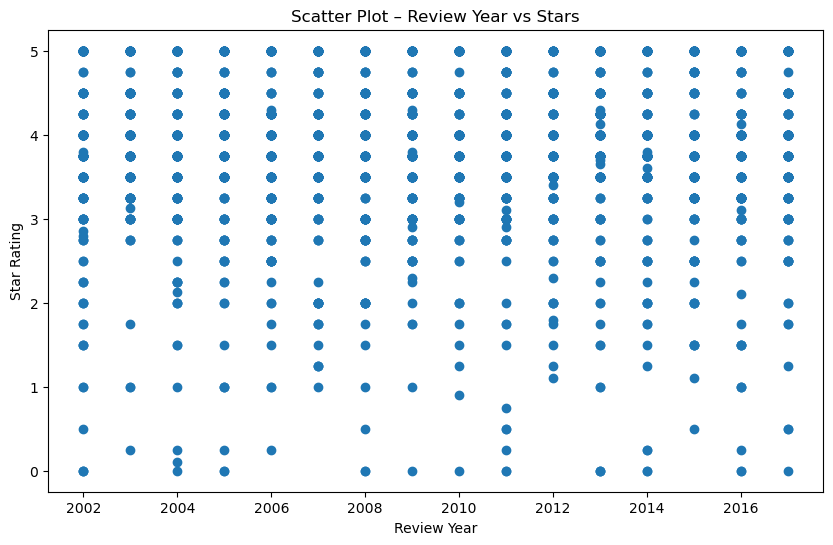

In [ ]:
#scatterplot, review year vs stars

plt.figure(figsize=(10,6))
plt.scatter(df["Year"], df["Stars"])
plt.title("Scatter Plot – Review Year vs Stars")
plt.xlabel("Review Year")
plt.ylabel("Star Rating")
plt.show()

All years experienced higher concentration of stars in the 2.0+ ratings, besides 2004. All years experienced more uniform distribution around 3,0+ ratings.

# End of Notebook Reflection

The chart that helped me the most was the heatmap of average star ratings by country and style. I feel like it helped me the most because it explored the relationships between multiple variables rather than just the correlation between one specific column and its data. This provides greater insight to what factors influence star ratings. The lack of year data inclusion in the dataset surprised me, as I believe it would be good for a reviewer of this set to be able to analyze yearly trends to explore certain facets of the data, such as if certain countries began to improve in quality and popularity. The visualizations help view the data as information in context such as comparison. With 2577 entries, it is impossible to identify trends just through visually scanning through rows of information.